# VELVETFRUIT_EXTRACT Option Analysis
Analyzes the underlying and voucher (call option) markets across days 1–3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR   = '.'
DAYS       = [1, 2, 3]
TS_PER_DAY = 1_000_000          # timestamps run 0 … 999_900 (step 100)
TOTAL_TIME = len(DAYS) * TS_PER_DAY

UNDERLYING = 'VELVETFRUIT_EXTRACT'
OPTION_PRODUCTS = [
    'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100',
    'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
    'VEV_6000', 'VEV_6500',
]
STRIKES = {p: int(p.split('_')[1]) for p in OPTION_PRODUCTS}
print('Strikes:', STRIKES)

Strikes: {'VEV_4000': 4000, 'VEV_4500': 4500, 'VEV_5000': 5000, 'VEV_5100': 5100, 'VEV_5200': 5200, 'VEV_5300': 5300, 'VEV_5400': 5400, 'VEV_5500': 5500, 'VEV_6000': 6000, 'VEV_6500': 6500}


## 1. Load & preprocess

In [2]:
frames = []
for d in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_4_day_{d}.csv', sep=';')
    frames.append(df)
raw = pd.concat(frames, ignore_index=True)

# Global timestamp: counts across the full 3-day window
raw['global_ts'] = (raw['day'] - 1) * TS_PER_DAY + raw['timestamp']

# Best mid = average of best bid and best ask (already provided, but recompute for safety)
raw['mid'] = np.where(
    raw['bid_price_1'].notna() & raw['ask_price_1'].notna(),
    (raw['bid_price_1'] + raw['ask_price_1']) / 2,
    raw['mid_price'],
)

print(raw.shape)
raw[['day', 'timestamp', 'global_ts', 'product', 'bid_price_1', 'ask_price_1', 'mid']].head(10)

(360000, 19)


,day,timestamp,global_ts,product,bid_price_1,ask_price_1,mid
0,1,0,0,VELVETFRUIT_EXTRACT,5242,5248,5245.0
1,1,0,0,HYDROGEL_PACK,9950,9966,9958.0
2,1,0,0,VEV_6000,0,1,0.5
3,1,0,0,VEV_5000,248,254,251.0
4,1,0,0,VEV_6500,0,1,0.5
5,1,0,0,VEV_5300,46,48,47.0
6,1,0,0,VEV_5400,16,17,16.5
7,1,0,0,VEV_4000,1235,1255,1245.0
8,1,0,0,VEV_5100,163,167,165.0
9,1,0,0,VEV_5200,94,97,95.5


## 2. Pivot into a wide aligned table

In [3]:
products_of_interest = [UNDERLYING] + OPTION_PRODUCTS
sub = raw[raw['product'].isin(products_of_interest)][['global_ts', 'product', 'mid']].copy()

wide = sub.pivot_table(index='global_ts', columns='product', values='mid', aggfunc='last')
wide = wide.sort_index()

# Forward-fill sparse ticks, then drop leading NaNs
wide = wide.ffill().dropna(subset=[UNDERLYING])

# Time to expiry (fraction of total lifespan remaining)
wide['T'] = ((TOTAL_TIME - wide.index.to_series().values) / TOTAL_TIME).clip(0, None)

S = wide[UNDERLYING]
print('Aligned rows:', len(wide))
print('Underlying price range: {:.1f} – {:.1f}'.format(S.min(), S.max()))
wide[[UNDERLYING] + OPTION_PRODUCTS[:4]].head()

Aligned rows: 30000
Underlying price range: 5191.5 – 5300.0


product,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100
global_ts,,,,,
0,5245.0,1245.0,745.0,251.0,165.0
100,5245.5,1245.5,746.0,252.0,166.0
200,5246.5,1246.5,746.0,252.0,166.0
300,5247.5,1247.5,747.0,254.0,167.0
400,5247.5,1247.5,747.0,254.0,167.0


## 3. Intrinsic value, time value, and realised volatility

In [4]:
# ── Intrinsic and time value per option ──────────────────────────────────────
intrinsic = pd.DataFrame(index=wide.index)
time_val  = pd.DataFrame(index=wide.index)
mkt_price = pd.DataFrame(index=wide.index)

for prod in OPTION_PRODUCTS:
    if prod not in wide.columns:
        continue
    K   = STRIKES[prod]
    IV  = np.maximum(S - K, 0)
    MP  = wide[prod].ffill()
    TV  = MP - IV
    intrinsic[prod] = IV
    time_val[prod]  = TV
    mkt_price[prod] = MP

# ── Realised volatility (rolling 500-tick log-returns of underlying) ──────────
ROLL_WIN = 500
log_ret  = np.log(S / S.shift(1)).dropna()
rvol     = log_ret.rolling(ROLL_WIN).std() * np.sqrt(ROLL_WIN)  # scaled vol estimate
wide['rvol'] = rvol

print('Realised vol stats:')
print(rvol.dropna().describe())

Realised vol stats:
count    29500.000000
mean         0.004844
std          0.000184
min          0.004329
25%          0.004712
50%          0.004825
75%          0.004957
max          0.005467
Name: VELVETFRUIT_EXTRACT, dtype: float64


## 4. Theoretical price proxy and mispricing

In [5]:
# Simple proxy: Intrinsic + c * σ * √T
# c is calibrated so the proxy fits ATM options on average
C_SCALE = 0.40   # empirical scaling constant (tune below)

sigma = wide['rvol'].ffill()
T_vec = wide['T']

theory   = pd.DataFrame(index=wide.index)
mispricing = pd.DataFrame(index=wide.index)   # market – theory  (positive ⟹ overpriced)

for prod in OPTION_PRODUCTS:
    if prod not in mkt_price.columns:
        continue
    K       = STRIKES[prod]
    IV      = intrinsic[prod]
    th      = IV + C_SCALE * sigma * np.sqrt(T_vec) * S  # scale by S for dimensionality
    theory[prod]     = th
    mispricing[prod] = mkt_price[prod] - th

# ── Calibrate C_SCALE to minimise mean absolute error on ATM options ──────────
atm_options = [p for p in OPTION_PRODUCTS if abs(STRIKES[p] - S.mean()) < 400]
print('ATM-ish options used for calibration:', atm_options)

best_c, best_mae = C_SCALE, np.inf
for c in np.arange(0.05, 1.5, 0.05):
    mae = 0
    for prod in atm_options:
        K  = STRIKES[prod]
        IV = intrinsic[prod]
        th = IV + c * sigma * np.sqrt(T_vec) * S
        mae += (mkt_price[prod] - th).abs().mean()
    if mae < best_mae:
        best_mae, best_c = mae, c

print(f'Calibrated c = {best_c:.2f}  (MAE = {best_mae:.2f})')
C_SCALE = best_c

# Recompute with calibrated constant
for prod in OPTION_PRODUCTS:
    if prod not in mkt_price.columns:
        continue
    K   = STRIKES[prod]
    IV  = intrinsic[prod]
    th  = IV + C_SCALE * sigma * np.sqrt(T_vec) * S
    theory[prod]     = th
    mispricing[prod] = mkt_price[prod] - th

ATM-ish options used for calibration: ['VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500']
Calibrated c = 0.70  (MAE = 79.49)


## 5. Time-series plots

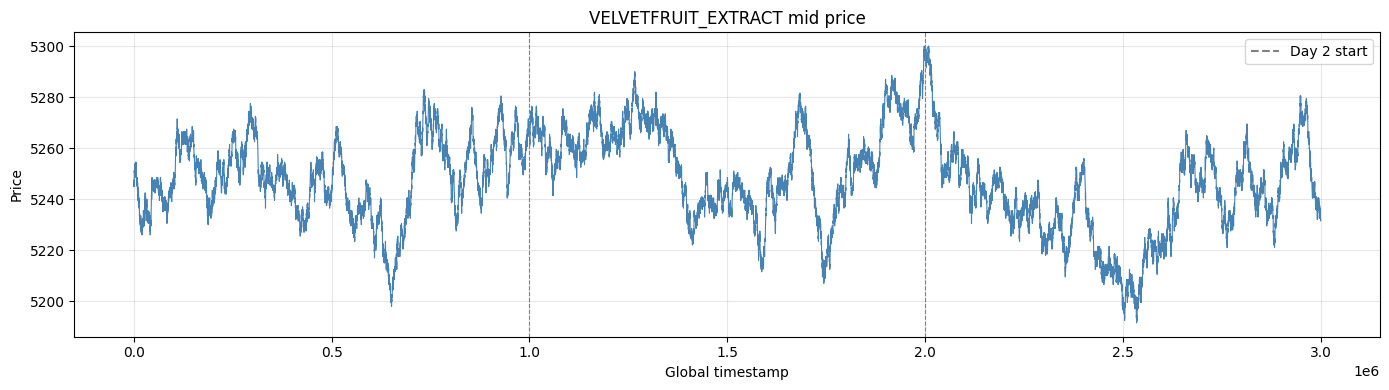

In [6]:
# ── 5a. Underlying price ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(wide.index, S, lw=0.8, color='steelblue')
for d in DAYS[1:]:
    ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.8, ls='--', label=f'Day {d} start')
ax.set_title('VELVETFRUIT_EXTRACT mid price')
ax.set_xlabel('Global timestamp'); ax.set_ylabel('Price')
handles = [plt.Line2D([0],[0], color='grey', ls='--')]
ax.legend(handles, [f'Day {d} start' for d in DAYS[1:]])
plt.tight_layout(); plt.show()

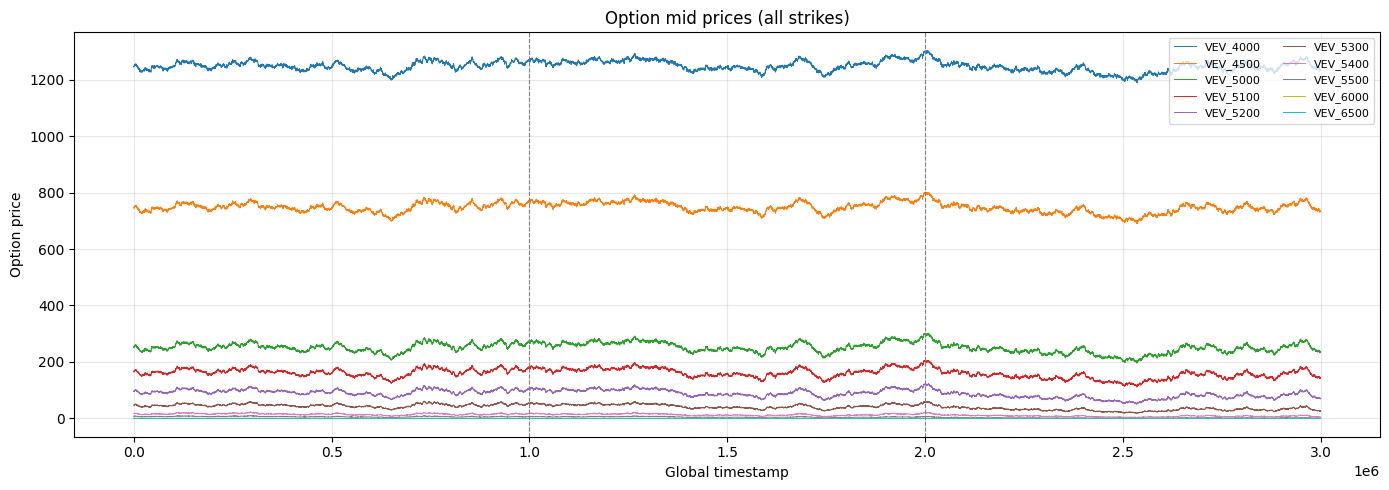

In [7]:
# ── 5b. Option mid prices ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', len(OPTION_PRODUCTS))
for i, prod in enumerate(OPTION_PRODUCTS):
    if prod in mkt_price.columns:
        ax.plot(mkt_price.index, mkt_price[prod], lw=0.7, color=cmap(i), label=prod)
for d in DAYS[1:]:
    ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.8, ls='--')
ax.set_title('Option mid prices (all strikes)')
ax.set_xlabel('Global timestamp'); ax.set_ylabel('Option price')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

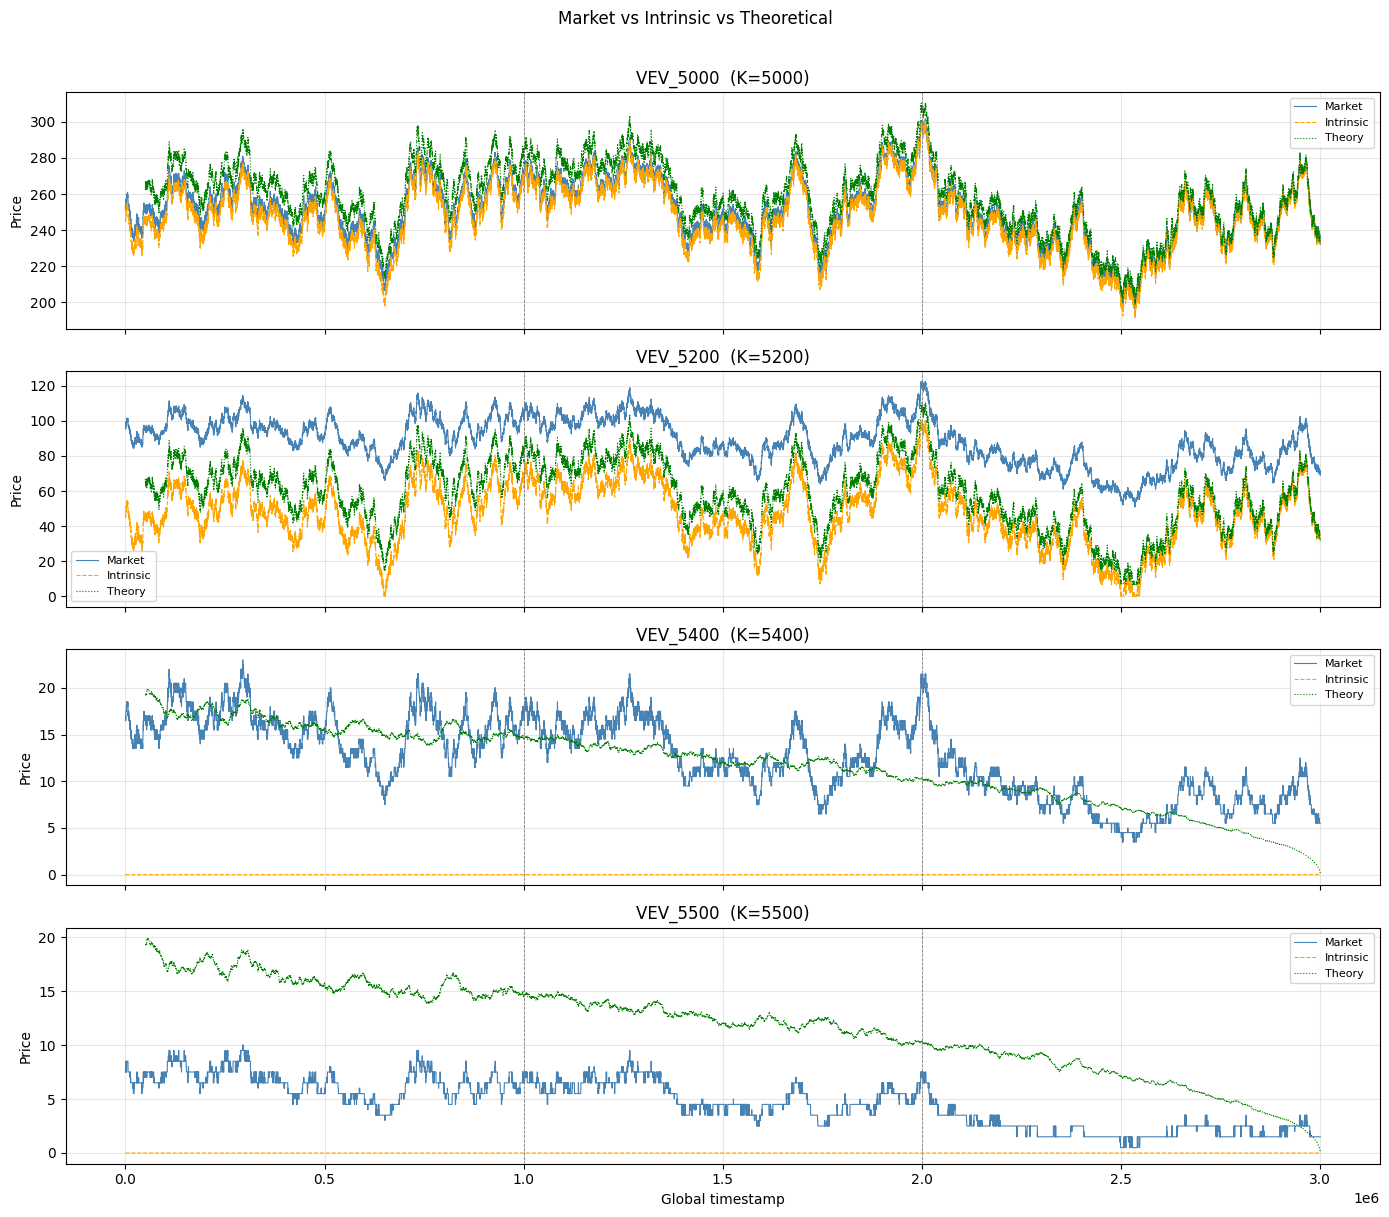

In [8]:
# ── 5c. Intrinsic vs market price for selected strikes ────────────────────────
sample_strikes = ['VEV_5000', 'VEV_5200', 'VEV_5400', 'VEV_5500']
sample_strikes = [p for p in sample_strikes if p in mkt_price.columns]

fig, axes = plt.subplots(len(sample_strikes), 1, figsize=(14, 3 * len(sample_strikes)), sharex=True)
for ax, prod in zip(axes, sample_strikes):
    ax.plot(mkt_price.index, mkt_price[prod], lw=0.8, label='Market', color='steelblue')
    ax.plot(intrinsic.index, intrinsic[prod], lw=0.8, label='Intrinsic', color='orange', ls='--')
    ax.plot(theory.index,    theory[prod],    lw=0.8, label='Theory',   color='green',  ls=':')
    ax.set_ylabel('Price'); ax.set_title(f'{prod}  (K={STRIKES[prod]})')
    ax.legend(fontsize=8)
    for d in DAYS[1:]:
        ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.6, ls='--')
axes[-1].set_xlabel('Global timestamp')
plt.suptitle('Market vs Intrinsic vs Theoretical', y=1.01)
plt.tight_layout(); plt.show()

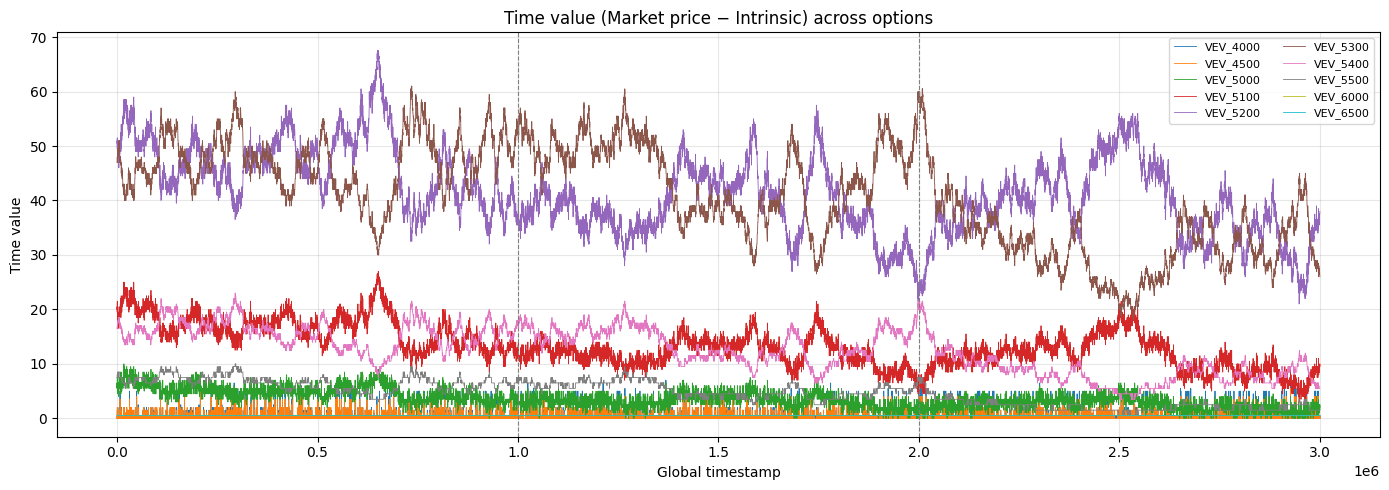

In [9]:
# ── 5d. Time value decay ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', len(OPTION_PRODUCTS))
for i, prod in enumerate(OPTION_PRODUCTS):
    if prod in time_val.columns:
        tv = time_val[prod].clip(lower=0)   # negative time value = distortion
        ax.plot(tv.index, tv, lw=0.6, color=cmap(i), label=prod)
for d in DAYS[1:]:
    ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.8, ls='--')
ax.set_title('Time value (Market price − Intrinsic) across options')
ax.set_xlabel('Global timestamp'); ax.set_ylabel('Time value')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

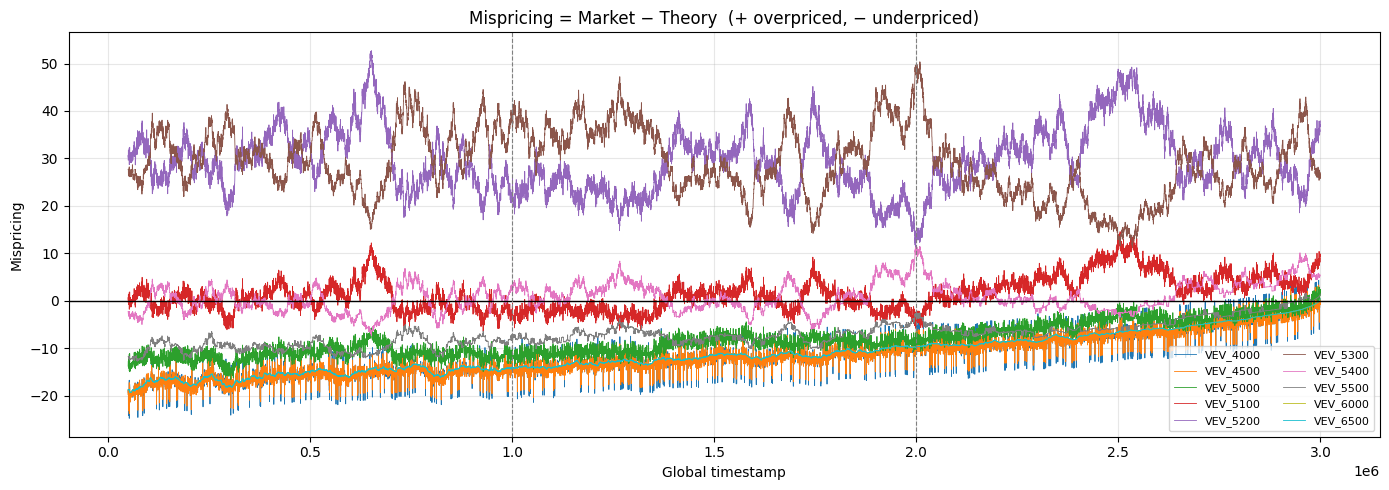

In [10]:
# ── 5e. Mispricing time series ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', len(OPTION_PRODUCTS))
for i, prod in enumerate(OPTION_PRODUCTS):
    if prod in mispricing.columns:
        ax.plot(mispricing.index, mispricing[prod], lw=0.6, color=cmap(i), label=prod)
ax.axhline(0, color='black', lw=1)
for d in DAYS[1:]:
    ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.8, ls='--')
ax.set_title('Mispricing = Market − Theory  (+ overpriced, − underpriced)')
ax.set_xlabel('Global timestamp'); ax.set_ylabel('Mispricing')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

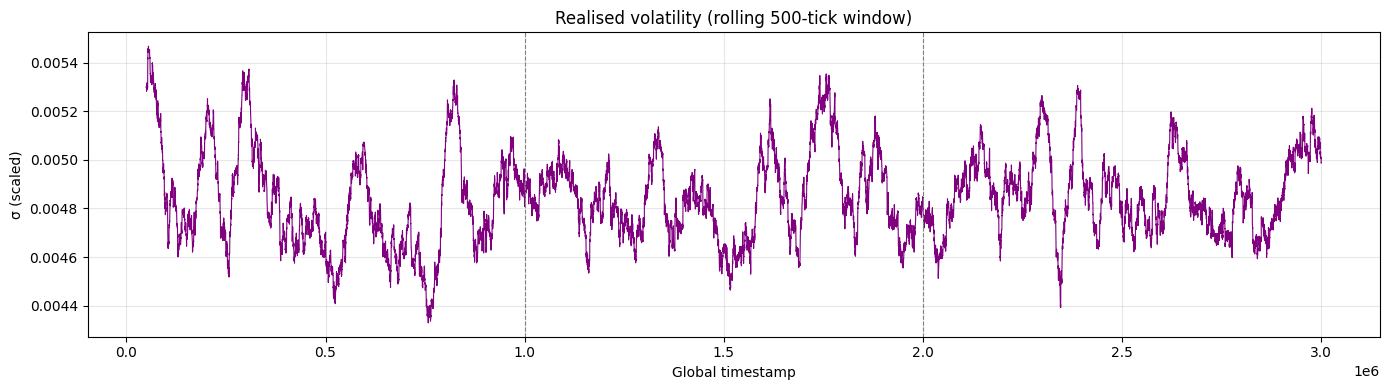

In [11]:
# ── 5f. Realised volatility ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(wide.index, wide['rvol'], lw=0.8, color='purple')
for d in DAYS[1:]:
    ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.8, ls='--')
ax.set_title(f'Realised volatility (rolling {ROLL_WIN}-tick window)')
ax.set_xlabel('Global timestamp'); ax.set_ylabel('σ (scaled)')
plt.tight_layout(); plt.show()

## 6. Cross-sectional plots (strike vs price / time value)

In [13]:
def cross_section_at(global_ts_target, label=''):
    """Snap to nearest available timestamp and build cross-section."""
    idx = (wide.index - global_ts_target).argmin()
    ts  = wide.index[idx]
    s_val = S.iloc[idx]

    rows = []
    for prod in OPTION_PRODUCTS:
        if prod not in mkt_price.columns:
            continue
        K   = STRIKES[prod]
        mp  = mkt_price[prod].iloc[idx]
        iv  = max(s_val - K, 0)
        tv  = mp - iv
        th  = theory[prod].iloc[idx]
        rows.append({'strike': K, 'mkt': mp, 'intrinsic': iv,
                     'time_val': tv, 'theory': th, 'mispricing': mp - th})
    df = pd.DataFrame(rows).sort_values('strike')
    return df, ts, s_val, label

# Pick representative times: start, mid, near end of each day
snapshot_times = [
    (TS_PER_DAY * 0 + 10_000,    'Day1 early'),
    (TS_PER_DAY * 0 + 500_000,   'Day1 mid'),
    (TS_PER_DAY * 0 + 990_000,   'Day1 end'),
    (TS_PER_DAY * 1 + 500_000,   'Day2 mid'),
    (TS_PER_DAY * 2 + 10_000,    'Day3 early'),
    (TS_PER_DAY * 2 + 990_000,   'Day3 end'),
]

snapshots = [cross_section_at(t, lbl) for t, lbl in snapshot_times]
print('Snapshots ready.')

Snapshots ready.


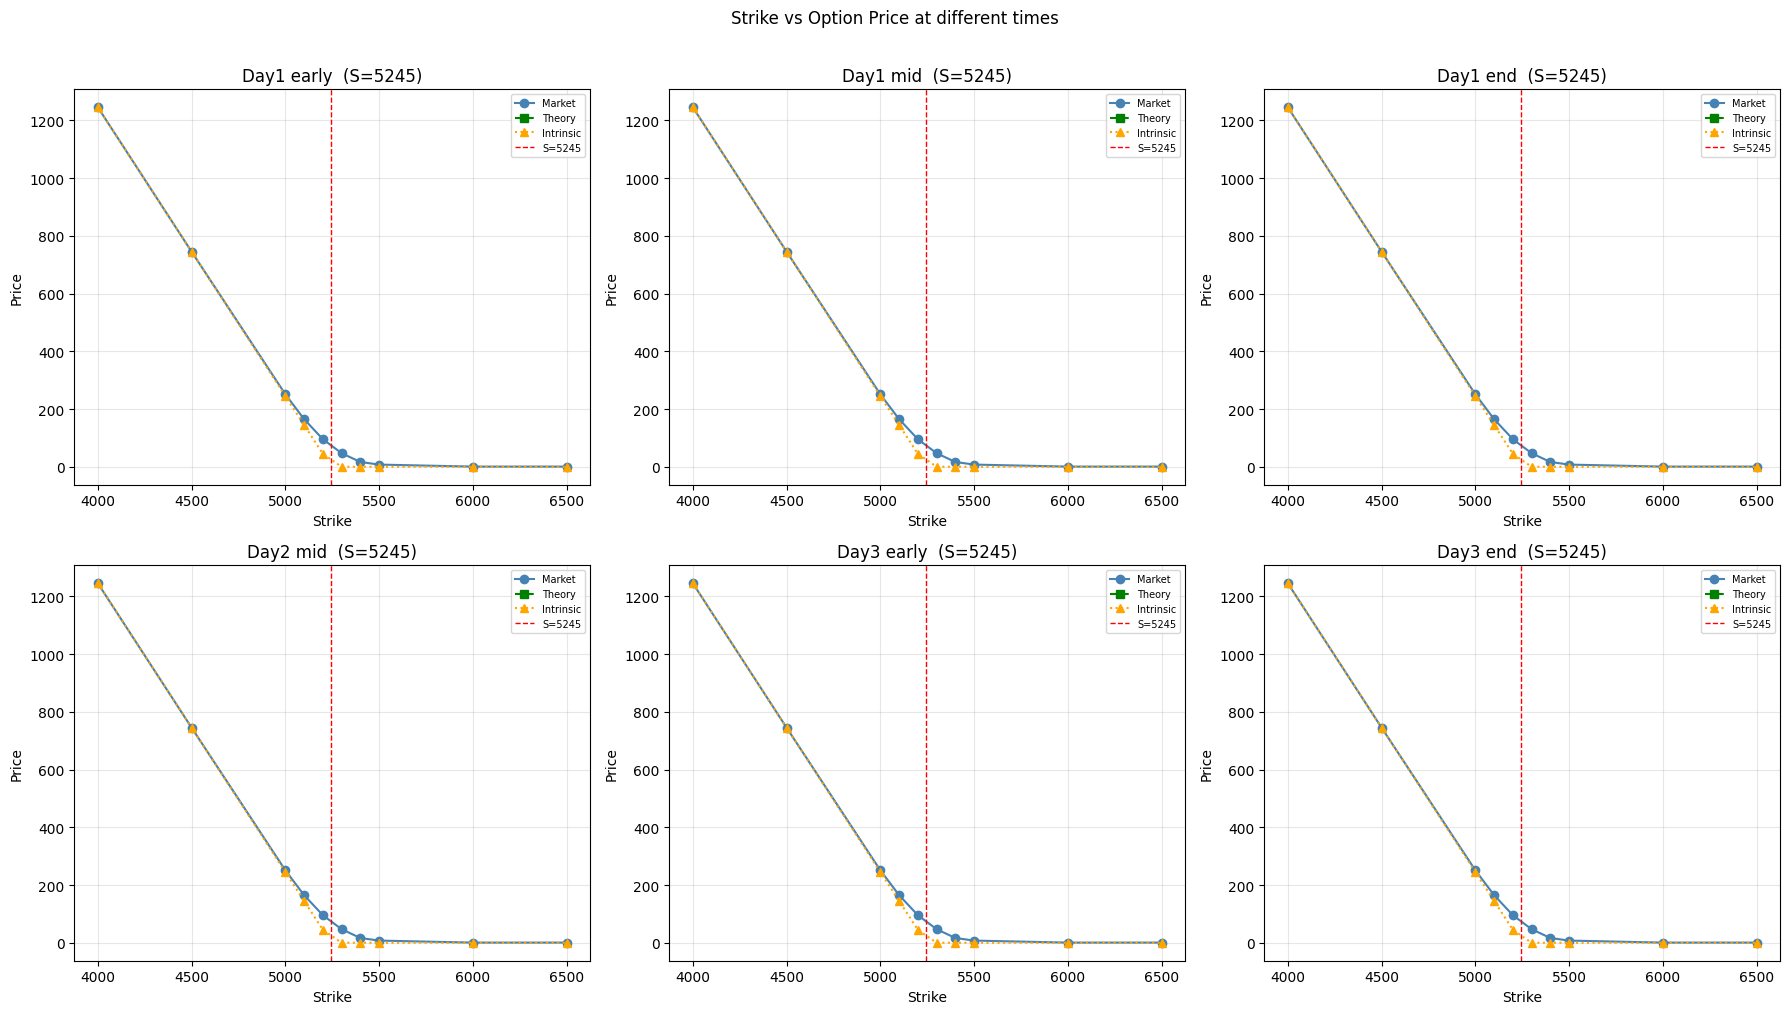

In [14]:
# ── 6a. Strike vs option price (market and theory) at each snapshot ───────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()
for ax, (df, ts, s_val, lbl) in zip(axes, snapshots):
    ax.plot(df['strike'], df['mkt'],       'o-', label='Market',    color='steelblue')
    ax.plot(df['strike'], df['theory'],    's--', label='Theory',   color='green')
    ax.plot(df['strike'], df['intrinsic'], '^:', label='Intrinsic', color='orange')
    ax.axvline(s_val, color='red', lw=1, ls='--', label=f'S={s_val:.0f}')
    ax.set_title(f'{lbl}  (S={s_val:.0f})')
    ax.set_xlabel('Strike'); ax.set_ylabel('Price')
    ax.legend(fontsize=7)
plt.suptitle('Strike vs Option Price at different times', y=1.01)
plt.tight_layout(); plt.show()

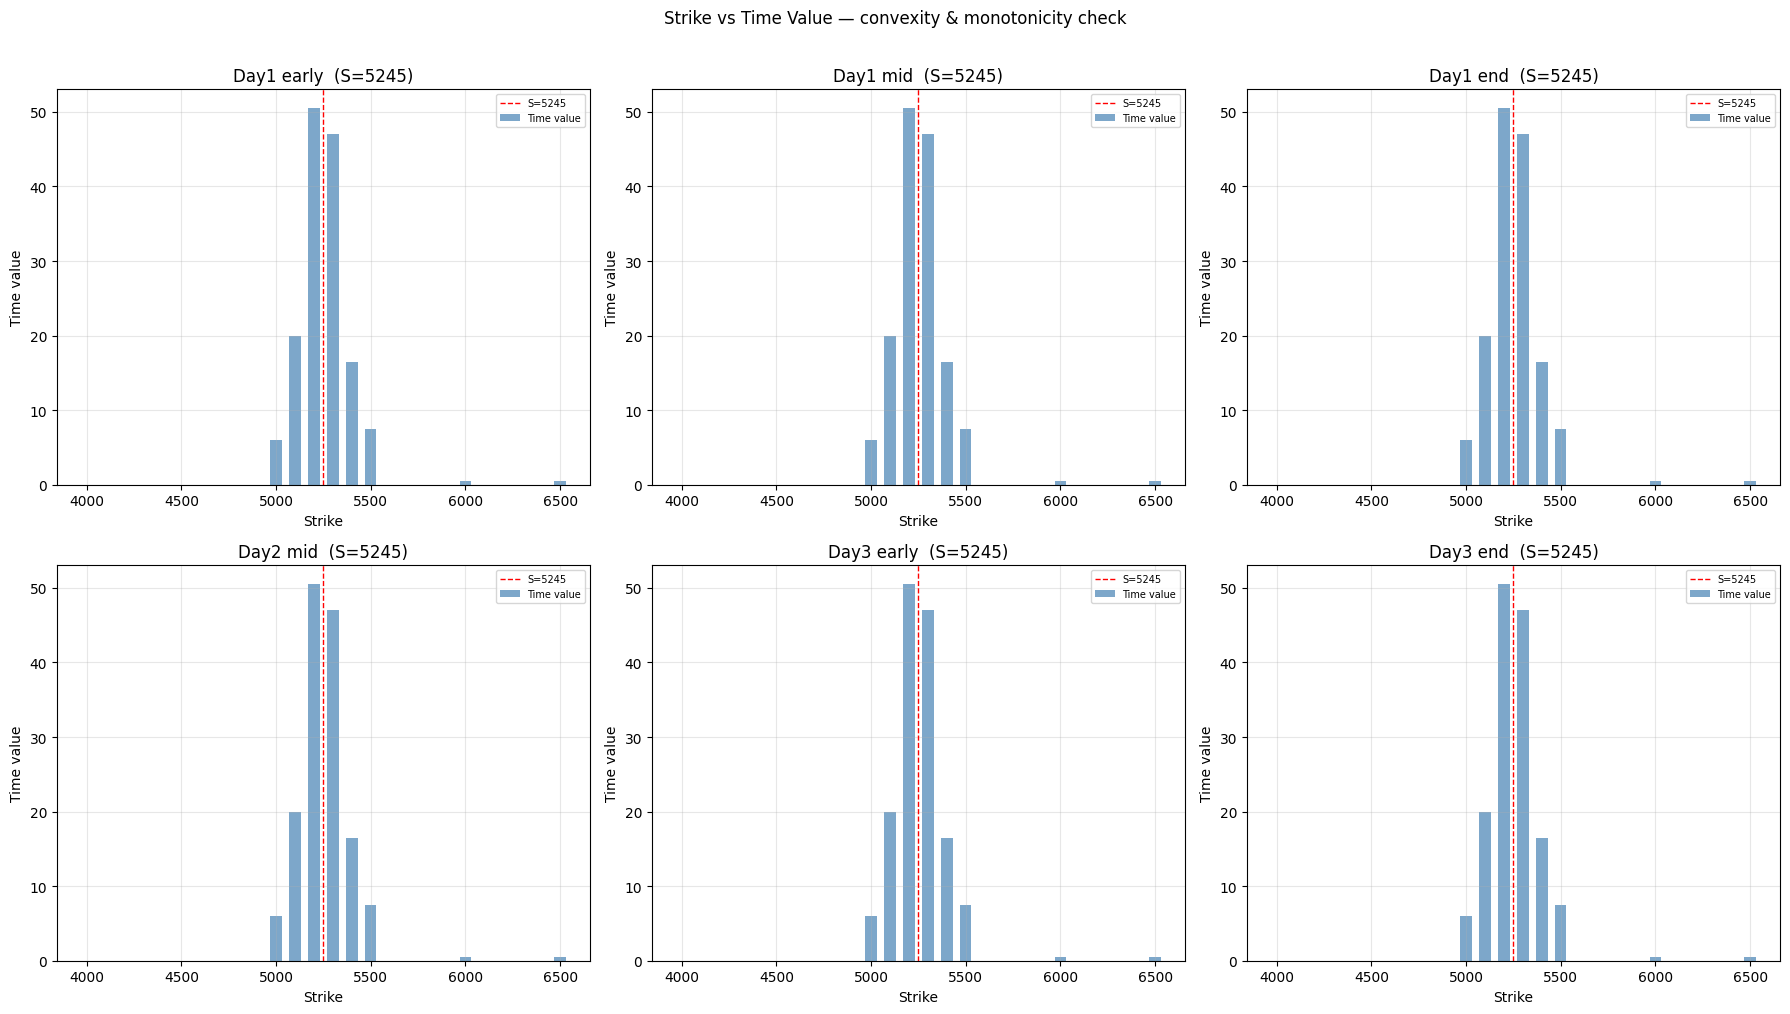

In [15]:
# ── 6b. Strike vs time value (check convexity and monotonicity) ───────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()
for ax, (df, ts, s_val, lbl) in zip(axes, snapshots):
    ax.bar(df['strike'], df['time_val'].clip(lower=0), width=60,
           color='steelblue', alpha=0.7, label='Time value')
    # Mark negative time values (arbitrage violations)
    neg = df[df['time_val'] < 0]
    if not neg.empty:
        ax.scatter(neg['strike'], neg['time_val'], color='red', zorder=5,
                   label='Negative TV (!)')
    ax.axvline(s_val, color='red', lw=1, ls='--', label=f'S={s_val:.0f}')
    ax.set_title(f'{lbl}  (S={s_val:.0f})')
    ax.set_xlabel('Strike'); ax.set_ylabel('Time value')
    ax.legend(fontsize=7)
plt.suptitle('Strike vs Time Value — convexity & monotonicity check', y=1.01)
plt.tight_layout(); plt.show()

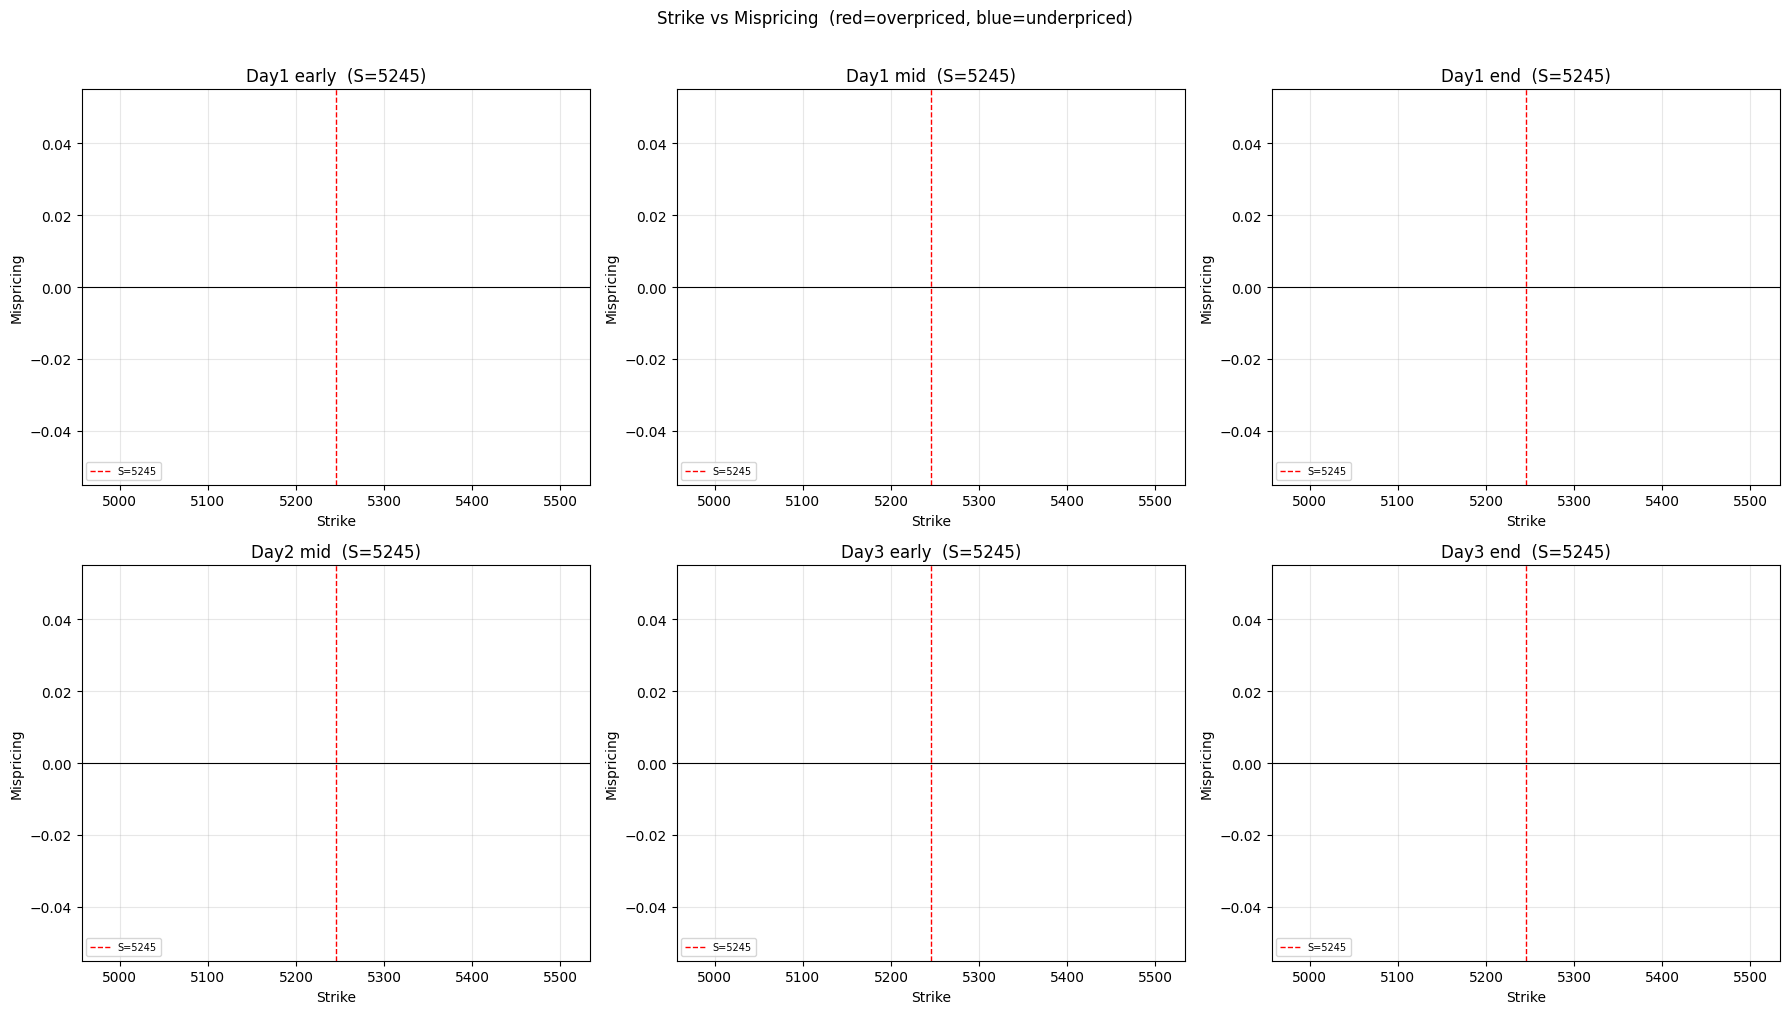

In [16]:
# ── 6c. Strike vs mispricing at each snapshot ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()
for ax, (df, ts, s_val, lbl) in zip(axes, snapshots):
    colors = ['tomato' if x > 0 else 'steelblue' for x in df['mispricing']]
    ax.bar(df['strike'], df['mispricing'], width=60, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(s_val, color='red', lw=1, ls='--', label=f'S={s_val:.0f}')
    ax.set_title(f'{lbl}  (S={s_val:.0f})')
    ax.set_xlabel('Strike'); ax.set_ylabel('Mispricing')
    ax.legend(fontsize=7)
plt.suptitle('Strike vs Mispricing  (red=overpriced, blue=underpriced)', y=1.01)
plt.tight_layout(); plt.show()

## 7. Anomaly detection — monotonicity and convexity violations

In [17]:
# Sample every 1000 ticks for speed
sample_idx = wide.index[::1000]

mono_violations   = {prod: [] for prod in OPTION_PRODUCTS}
convex_violations = {prod: [] for prod in OPTION_PRODUCTS}

sorted_products = sorted(OPTION_PRODUCTS, key=lambda p: STRIKES[p])

for ts in sample_idx:
    row_idx = wide.index.get_loc(ts)
    prices  = {p: mkt_price[p].iloc[row_idx] for p in sorted_products if p in mkt_price.columns}
    ks      = sorted(prices.keys(), key=lambda p: STRIKES[p])

    # Monotonicity: call price should decrease as strike increases
    for i in range(len(ks) - 1):
        if prices[ks[i]] < prices[ks[i+1]]:
            mono_violations[ks[i]].append(ts)

    # Convexity: C(K1) + C(K3) >= 2*C(K2) for equally spaced strikes
    # Approximate check for any three consecutive strikes
    for i in range(1, len(ks) - 1):
        k1, k2, k3 = ks[i-1], ks[i], ks[i+1]
        K1, K2, K3 = STRIKES[k1], STRIKES[k2], STRIKES[k3]
        lam = (K3 - K2) / (K3 - K1) if K3 != K1 else 0.5
        expected_mid = lam * prices[k1] + (1 - lam) * prices[k3]
        if prices[k2] > expected_mid + 1:   # +1 for rounding tolerance
            convex_violations[k2].append(ts)

print('Monotonicity violation counts per option:')
for p in sorted_products:
    print(f'  {p}: {len(mono_violations[p])}')

print('\nConvexity violation counts per option:')
for p in sorted_products:
    print(f'  {p}: {len(convex_violations[p])}')

Monotonicity violation counts per option:
  VEV_4000: 0
  VEV_4500: 0
  VEV_5000: 0
  VEV_5100: 0
  VEV_5200: 0
  VEV_5300: 0
  VEV_5400: 0
  VEV_5500: 0
  VEV_6000: 0
  VEV_6500: 0

Convexity violation counts per option:
  VEV_4000: 0
  VEV_4500: 0
  VEV_5000: 0
  VEV_5100: 0
  VEV_5200: 0
  VEV_5300: 0
  VEV_5400: 0
  VEV_5500: 0
  VEV_6000: 0
  VEV_6500: 0


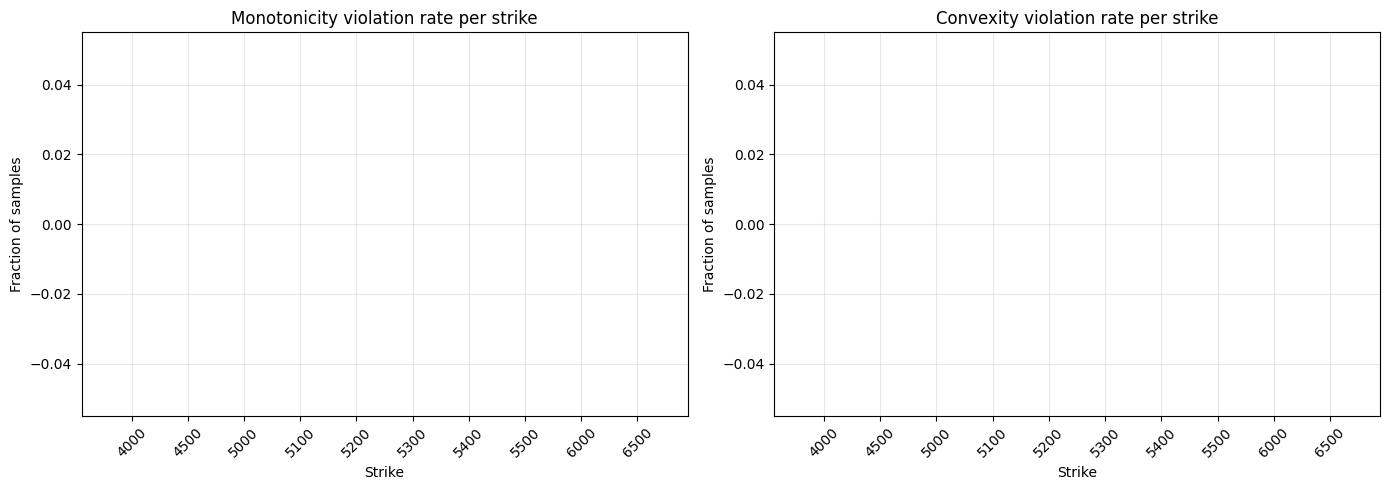

In [18]:
# ── Violation rate chart ──────────────────────────────────────────────────────
n_samples = len(sample_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mono_rates   = [len(mono_violations[p]) / n_samples for p in sorted_products]
convex_rates = [len(convex_violations[p]) / n_samples for p in sorted_products]
labels = [p.replace('VEV_', '') for p in sorted_products]

axes[0].bar(labels, mono_rates, color='tomato', alpha=0.8)
axes[0].set_title('Monotonicity violation rate per strike')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Fraction of samples')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(labels, convex_rates, color='steelblue', alpha=0.8)
axes[1].set_title('Convexity violation rate per strike')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Fraction of samples')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

## 8. Summary statistics and persistent mispricing

In [19]:
summary_rows = []
for prod in sorted_products:
    if prod not in mkt_price.columns:
        continue
    K    = STRIKES[prod]
    mp   = mkt_price[prod].dropna()
    iv   = intrinsic[prod].reindex(mp.index)
    tv   = time_val[prod].reindex(mp.index)
    mis  = mispricing[prod].reindex(mp.index)
    summary_rows.append({
        'Product':          prod,
        'Strike':           K,
        'Avg Market Price': mp.mean(),
        'Avg Intrinsic':    iv.mean(),
        'Avg Time Value':   tv.mean(),
        'Avg Mispricing':   mis.mean(),
        'Std Mispricing':   mis.std(),
        'Pct Overpriced':   (mis > 5).mean() * 100,
        'Pct Underpriced':  (mis < -5).mean() * 100,
        'Neg TV %':         (tv < 0).mean() * 100,
        'Mono Violation %': len(mono_violations[prod]) / n_samples * 100,
        'Convex Viol %':    len(convex_violations[prod]) / n_samples * 100,
    })

summary = pd.DataFrame(summary_rows).set_index('Product')
pd.set_option('display.float_format', '{:.2f}'.format)
summary

,Strike,Avg Market Price,Avg Intrinsic,Avg Time Value,Avg Mispricing,Std Mispricing,Pct Overpriced,Pct Underpriced,Neg TV %,Mono Violation %,Convex Viol %
Product,,,,,,,,,,,
VEV_4000,4000,1247.66,1247.65,0.01,-11.75,4.27,0.00,89.87,11.07,0.00,0.00
VEV_4500,4500,747.66,747.65,0.01,-11.75,4.25,0.00,90.01,28.32,0.00,0.00
VEV_5000,5000,251.14,247.65,3.50,-8.32,3.40,0.00,77.72,0.10,0.00,0.00
VEV_5100,5100,160.86,147.65,13.21,1.32,3.49,14.42,0.39,0.00,0.00,0.00
VEV_5200,5200,88.99,47.66,41.33,29.37,6.68,98.33,0.00,0.00,0.00,0.00
VEV_5300,5300,41.18,0.00,41.18,29.37,7.08,98.33,0.00,0.00,0.00,0.00
VEV_5400,5400,12.63,0.00,12.63,0.83,2.99,9.22,1.65,0.00,0.00,0.00
VEV_5500,5500,4.71,0.00,4.71,-7.08,2.67,0.00,81.28,0.00,0.00,0.00
VEV_6000,6000,0.50,0.00,0.50,-11.25,4.18,0.00,88.66,0.00,0.00,0.00


In [20]:
# ── Highlight extremes ────────────────────────────────────────────────────────
most_over  = summary['Avg Mispricing'].idxmax()
most_under = summary['Avg Mispricing'].idxmin()
most_neg_tv = summary['Neg TV %'].idxmax()

print(f'Most overpriced on average : {most_over}  '
      f'(avg mispricing = {summary.loc[most_over, "Avg Mispricing"]:+.2f})')
print(f'Most underpriced on average: {most_under}  '
      f'(avg mispricing = {summary.loc[most_under, "Avg Mispricing"]:+.2f})')
print(f'Highest negative time value: {most_neg_tv}  '
      f'({summary.loc[most_neg_tv, "Neg TV %"]:.1f}% of ticks)')

Most overpriced on average : VEV_5200  (avg mispricing = +29.37)
Most underpriced on average: VEV_4000  (avg mispricing = -11.75)
Highest negative time value: VEV_4500  (28.3% of ticks)


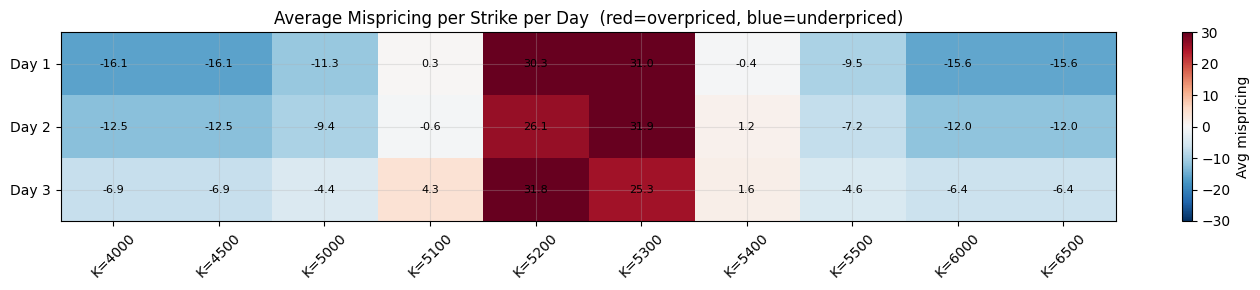

In [21]:
# ── Final heatmap: average mispricing by strike and day ───────────────────────
heat_rows = []
for d in DAYS:
    day_start = (d - 1) * TS_PER_DAY
    day_end   = d * TS_PER_DAY
    mask = (mispricing.index >= day_start) & (mispricing.index < day_end)
    row = {'Day': d}
    for prod in sorted_products:
        if prod in mispricing.columns:
            row[prod] = mispricing.loc[mask, prod].mean()
    heat_rows.append(row)

heat = pd.DataFrame(heat_rows).set_index('Day')
heat.columns = [c.replace('VEV_', 'K=') for c in heat.columns]

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(heat.values, aspect='auto', cmap='RdBu_r', vmin=-30, vmax=30)
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=45)
ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels([f'Day {d}' for d in DAYS])
plt.colorbar(im, ax=ax, label='Avg mispricing')
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        v = heat.values[r, c]
        if not np.isnan(v):
            ax.text(c, r, f'{v:.1f}', ha='center', va='center', fontsize=8)
ax.set_title('Average Mispricing per Strike per Day  (red=overpriced, blue=underpriced)')
plt.tight_layout(); plt.show()

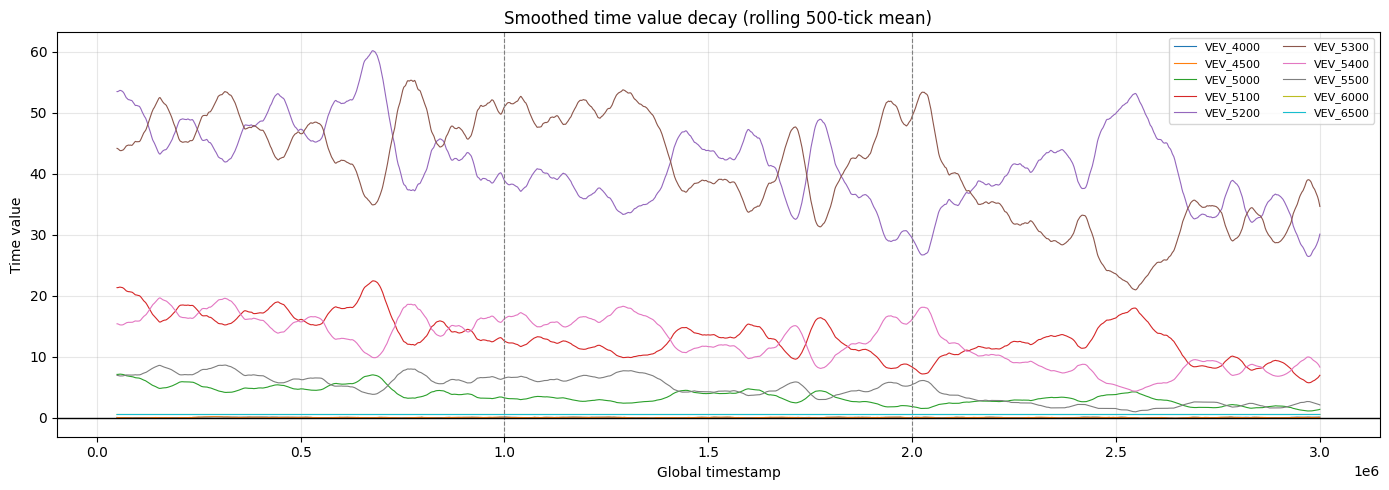


=== Analysis complete ===


In [22]:
# ── Time value decay end-of-day check ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.get_cmap('tab10', len(sorted_products))
for i, prod in enumerate(sorted_products):
    if prod not in time_val.columns:
        continue
    tv = time_val[prod].rolling(500).mean()  # smoothed
    ax.plot(tv.index, tv, lw=0.8, color=cmap(i), label=prod)

for d in DAYS[1:]:
    ax.axvline((d - 1) * TS_PER_DAY, color='grey', lw=0.8, ls='--')
ax.axhline(0, color='black', lw=1)
ax.set_title('Smoothed time value decay (rolling 500-tick mean)')
ax.set_xlabel('Global timestamp'); ax.set_ylabel('Time value')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

print('\n=== Analysis complete ===')

---
## 9. Voucher Arbitrage Analysis

Systematic check of every model-free no-arbitrage condition between vouchers:
1. **Negative time value** — option price < intrinsic (buy & exercise)
2. **Monotonicity** — lower strike call must be worth >= higher strike call
3. **Bull spread upper bound** — C(K_lo) - C(K_hi) <= K_hi - K_lo
4. **Butterfly / convexity** — C(K_mid) <= lam·C(K_lo) + (1-lam)·C(K_hi)

All checks are run at *executable* bid/ask prices to filter out apparent violations that disappear after crossing the spread.

In [23]:
# ── Rebuild bid/ask tables ────────────────────────────────────────────────────
products_all = [UNDERLYING] + OPTION_PRODUCTS
sub_ba = raw[raw['product'].isin(products_all)][
    ['global_ts', 'product', 'mid', 'bid_price_1', 'ask_price_1']].copy()

bid_tbl = sub_ba.pivot_table(index='global_ts', columns='product',
                              values='bid_price_1', aggfunc='last').sort_index().ffill()
ask_tbl = sub_ba.pivot_table(index='global_ts', columns='product',
                              values='ask_price_1', aggfunc='last').sort_index().ffill()
mid_tbl = sub_ba.pivot_table(index='global_ts', columns='product',
                              values='mid', aggfunc='last').sort_index().ffill()

sorted_opts = sorted(OPTION_PRODUCTS, key=lambda p: STRIKES[p])
S_mid = mid_tbl[UNDERLYING]

print('Tables built. S mean =', round(S_mid.mean(), 1))
print('Bid-ask spread per option:')
for p in sorted_opts:
    ba = (ask_tbl[p] - bid_tbl[p]).dropna()
    print(f'  {p}: mean={ba.mean():.2f}  median={ba.median():.0f}')

Tables built. S mean = 5247.6
Bid-ask spread per option:
  VEV_4000: mean=20.75  median=21
  VEV_4500: mean=15.79  median=16
  VEV_5000: mean=5.96  median=6
  VEV_5100: mean=4.17  median=4
  VEV_5200: mean=2.76  median=3
  VEV_5300: mean=1.97  median=2
  VEV_5400: mean=1.30  median=1
  VEV_5500: mean=1.11  median=1
  VEV_6000: mean=1.00  median=1
  VEV_6500: mean=1.00  median=1


In [24]:
# ── Check 1: Negative time value at executable prices ────────────────────────
print('CHECK 1 — NEGATIVE TIME VALUE (buy option at ask, exercise vs sell S at bid)')
print('Profit = max(bid_S - K, 0) - ask_option')
print()
any_neg_tv = False
for p in sorted_opts:
    K = STRIKES[p]
    if p not in ask_tbl.columns: continue
    profit = (bid_tbl[UNDERLYING] - K).clip(lower=0) - ask_tbl[p]
    mask   = profit > 0
    if mask.any():
        any_neg_tv = True
        print(f'  {p}: {mask.mean()*100:.2f}% of ticks profitable, '
              f'avg={profit[mask].mean():.2f}, max={profit.max():.2f}')

if not any_neg_tv:
    print('  None — all options price above intrinsic at executable prices.')

# ── Check 2: Monotonicity at executable prices ────────────────────────────────
print()
print('CHECK 2 — MONOTONICITY (sell hi-strike at bid > buy lo-strike at ask)')
print('Violation: bid(K_hi) > ask(K_lo) for K_hi > K_lo')
any_mono = False
for i, lo in enumerate(sorted_opts):
    for hi in sorted_opts[i+1:]:
        if lo not in ask_tbl.columns or hi not in bid_tbl.columns: continue
        viol = bid_tbl[hi] - ask_tbl[lo]  # positive => higher strike sells for more
        mask = viol > 0
        if mask.any():
            any_mono = True
            print(f'  {lo}/{hi}: {mask.mean()*100:.2f}% violated, '
                  f'avg={viol[mask].mean():.2f}, max={viol.max():.2f}')
if not any_mono:
    print('  None — monotonicity holds across all pairs.')

CHECK 1 — NEGATIVE TIME VALUE (buy option at ask, exercise vs sell S at bid)
Profit = max(bid_S - K, 0) - ask_option

  VEV_4000: 0.01% of ticks profitable, avg=1.00, max=1.00
  VEV_4500: 0.01% of ticks profitable, avg=1.00, max=1.00

CHECK 2 — MONOTONICITY (sell hi-strike at bid > buy lo-strike at ask)
Violation: bid(K_hi) > ask(K_lo) for K_hi > K_lo
  None — monotonicity holds across all pairs.


In [25]:
# ── Check 3: Bull spread upper bound at executable prices ─────────────────────
# Sell C(K_lo) at bid, buy C(K_hi) at ask => net credit <= K_hi - K_lo
# If credit > K_hi - K_lo => free money regardless of expiry
print('CHECK 3 — BULL SPREAD UPPER BOUND at bid/ask prices')
print('Sell K_lo at bid, buy K_hi at ask; net credit must be <= K_hi - K_lo')
print()

bull_results = []
for i, lo in enumerate(sorted_opts):
    for hi in sorted_opts[i+1:]:
        K_lo, K_hi = STRIKES[lo], STRIKES[hi]
        if lo not in bid_tbl.columns or hi not in ask_tbl.columns: continue
        net_credit = bid_tbl[lo] - ask_tbl[hi]
        arb_pnl    = net_credit - (K_hi - K_lo)
        mask       = arb_pnl > 0
        bull_results.append({
            'lo': lo, 'hi': hi,
            'K_diff': K_hi - K_lo,
            'avg_spread_mid': (mid_tbl[lo] - mid_tbl[hi]).mean(),
            'arb_pct': mask.mean() * 100,
            'arb_avg_pnl': arb_pnl[mask].mean() if mask.any() else 0,
            'arb_max_pnl': arb_pnl.max(),
        })
        if mask.any():
            print(f'  SELL {lo}/BUY {hi}: {mask.mean()*100:.2f}% of ticks, '
                  f'avg profit={arb_pnl[mask].mean():.2f}, max={arb_pnl.max():.2f}')

bull_df = pd.DataFrame(bull_results)
print()
print('Adjacent pairs — spread vs strike difference:')
adj = bull_df[bull_df.apply(
    lambda r: sorted_opts.index(r['hi']) == sorted_opts.index(r['lo']) + 1, axis=1)]
print(adj[['lo','hi','K_diff','avg_spread_mid','arb_pct','arb_max_pnl']].to_string(index=False))

CHECK 3 — BULL SPREAD UPPER BOUND at bid/ask prices
Sell K_lo at bid, buy K_hi at ask; net credit must be <= K_hi - K_lo


Adjacent pairs — spread vs strike difference:
      lo       hi  K_diff  avg_spread_mid  arb_pct  arb_max_pnl
VEV_4000 VEV_4500     500          500.00     0.00           -7
VEV_4500 VEV_5000     500          496.51     0.00           -4
VEV_5000 VEV_5100     100           90.28     0.00           -7
VEV_5100 VEV_5200     100           71.87     0.00          -19
VEV_5200 VEV_5300     100           47.82     0.00          -40
VEV_5300 VEV_5400     100           28.55     0.00          -62
VEV_5400 VEV_5500     100            7.92     0.00          -87
VEV_5500 VEV_6000     500            4.21     0.00         -492
VEV_6000 VEV_6500     500            0.00     0.00         -501


In [26]:
# ── Check 4: Butterfly (convexity) at executable prices ──────────────────────
# Buy lam units of lo (at ask) + (1-lam) units of hi (at ask), sell 1 of mid (at bid)
# Net cost < 0 => receive free credit with non-negative expiry payoff => arb
print('CHECK 4 — BUTTERFLY CONVEXITY at bid/ask prices')
print('Buy lam*C(K_lo)+( 1-lam)*C(K_hi) at ask, sell C(K_mid) at bid')
print()

fly_results = []
for i in range(len(sorted_opts)):
    for j in range(i+1, len(sorted_opts)):
        for k in range(j+1, len(sorted_opts)):
            lo, mid_o, hi = sorted_opts[i], sorted_opts[j], sorted_opts[k]
            K1, K2, K3 = STRIKES[lo], STRIKES[mid_o], STRIKES[hi]
            lam = (K3 - K2) / (K3 - K1)
            if not all(p in ask_tbl.columns and p in bid_tbl.columns
                       for p in [lo, mid_o, hi]):
                continue
            cost = lam * ask_tbl[lo] + (1 - lam) * ask_tbl[hi] - bid_tbl[mid_o]
            mask = cost < 0
            if mask.any():
                fly_results.append({
                    'lo': lo, 'mid': mid_o, 'hi': hi, 'lam': lam,
                    'arb_pct': mask.mean() * 100,
                    'avg_credit': (-cost[mask]).mean(),
                    'max_credit': (-cost).max(),
                })

if fly_results:
    fly_df = pd.DataFrame(fly_results).sort_values('arb_pct', ascending=False)
    print(fly_df.head(20).to_string(index=False))
else:
    print('  No butterfly arbitrage found at executable prices.')

CHECK 4 — BUTTERFLY CONVEXITY at bid/ask prices
Buy lam*C(K_lo)+( 1-lam)*C(K_hi) at ask, sell C(K_mid) at bid

  No butterfly arbitrage found at executable prices.


### 9b. Deep structural analysis — what do the spreads imply?

Even with no outright risk-free arbitrage, the *relative* pricing of the vouchers encodes a lot of information. The bull spread value `C(K_lo) - C(K_hi)` approximates the risk-neutral probability `P(S_T > K_lo)` scaled by the strike interval — this is the Breeden–Litzenberger digital option result. We can extract the implied terminal distribution and detect relative value dislocations.

In [27]:
# ── Breeden-Litzenberger: implied risk-neutral probabilities ──────────────────
# -dC/dK = P(S_T > K) under risk-neutral measure
# Approximate with adjacent bull spread value / strike difference

print('IMPLIED RISK-NEUTRAL SURVIVAL PROBABILITIES from spread values')
print(f'(Current S ~ {S_mid.mean():.0f})')
print()

rn_probs = []
for i in range(len(sorted_opts) - 1):
    lo, hi = sorted_opts[i], sorted_opts[i+1]
    K_lo, K_hi = STRIKES[lo], STRIKES[hi]
    spread_val = (mid_tbl[lo] - mid_tbl[hi]).mean()
    prob = spread_val / (K_hi - K_lo)
    rn_probs.append({'boundary': K_hi, 'P(S_T > K)': prob,
                     'spread_mean': spread_val, 'K_diff': K_hi - K_lo})
    bar = '#' * int(prob * 40)
    print(f'  P(S_T > {K_hi:5d}) = {prob:.3f}  |{bar:<40}|')

rn_df = pd.DataFrame(rn_probs)

# Implied terminal PDF: P(K_lo < S_T < K_hi) = P(S_T > K_lo) - P(S_T > K_hi)
print()
print('IMPLIED PROBABILITY MASS PER STRIKE INTERVAL:')
probs_above = [1.0] + list(rn_df['P(S_T > K)'])
probs_above = [min(p, 1.0) for p in probs_above]
boundaries  = [STRIKES[sorted_opts[0]]] + list(rn_df['boundary'])
for i in range(len(boundaries) - 1):
    mass = probs_above[i] - probs_above[i+1]
    bar  = '#' * max(0, int(mass * 80))
    print(f'  [{boundaries[i]:5d}, {boundaries[i+1]:5d}]  mass={mass:.3f}  |{bar:<50}|')

IMPLIED RISK-NEUTRAL SURVIVAL PROBABILITIES from spread values
(Current S ~ 5248)

  P(S_T >  4500) = 1.000  |####################################### |
  P(S_T >  5000) = 0.993  |####################################### |
  P(S_T >  5100) = 0.903  |####################################    |
  P(S_T >  5200) = 0.719  |############################            |
  P(S_T >  5300) = 0.478  |###################                     |
  P(S_T >  5400) = 0.285  |###########                             |
  P(S_T >  5500) = 0.079  |###                                     |
  P(S_T >  6000) = 0.008  |                                        |
  P(S_T >  6500) = 0.000  |                                        |

IMPLIED PROBABILITY MASS PER STRIKE INTERVAL:
  [ 4000,  4500]  mass=0.000  |                                                  |
  [ 4500,  5000]  mass=0.007  |                                                  |
  [ 5000,  5100]  mass=0.090  |#######                                           |


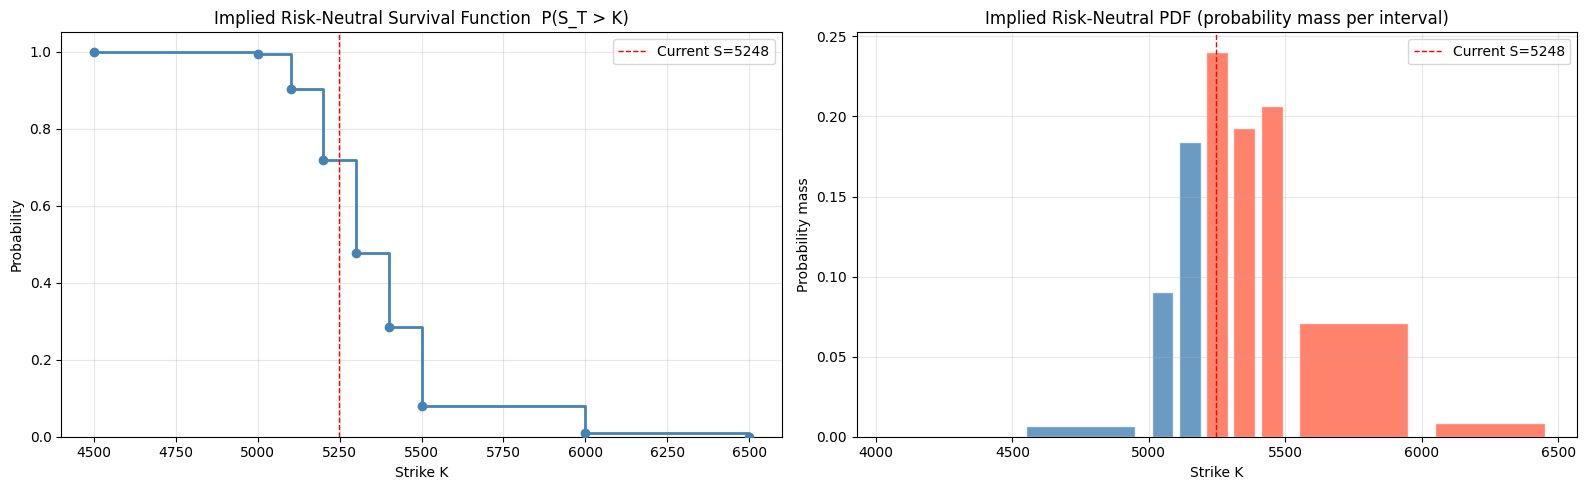

Blue = currently ITM region, Red = currently OTM region


In [28]:
# ── Plot 1: Implied survival curve + probability mass ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

strikes_plot = rn_df['boundary'].values
probs_plot   = rn_df['P(S_T > K)'].values

axes[0].step(strikes_plot, probs_plot, where='post', color='steelblue', lw=2)
axes[0].scatter(strikes_plot, probs_plot, color='steelblue', zorder=5)
axes[0].axvline(S_mid.mean(), color='red', ls='--', lw=1, label=f'Current S={S_mid.mean():.0f}')
axes[0].set_title('Implied Risk-Neutral Survival Function  P(S_T > K)')
axes[0].set_xlabel('Strike K'); axes[0].set_ylabel('Probability')
axes[0].legend(); axes[0].set_ylim(0, 1.05)

# Probability mass bars
mass_vals = [probs_above[i] - probs_above[i+1] for i in range(len(boundaries) - 1)]
mid_strikes = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(len(boundaries) - 1)]
widths = [boundaries[i+1] - boundaries[i] for i in range(len(boundaries) - 1)]

colors_m = ['steelblue' if boundaries[i+1] <= S_mid.mean() else 'tomato'
            for i in range(len(boundaries)-1)]
axes[1].bar(mid_strikes, mass_vals, width=[w*0.8 for w in widths],
            color=colors_m, alpha=0.8, edgecolor='white')
axes[1].axvline(S_mid.mean(), color='red', ls='--', lw=1, label=f'Current S={S_mid.mean():.0f}')
axes[1].set_title('Implied Risk-Neutral PDF (probability mass per interval)')
axes[1].set_xlabel('Strike K'); axes[1].set_ylabel('Probability mass')
axes[1].legend()

plt.tight_layout(); plt.show()
print('Blue = currently ITM region, Red = currently OTM region')

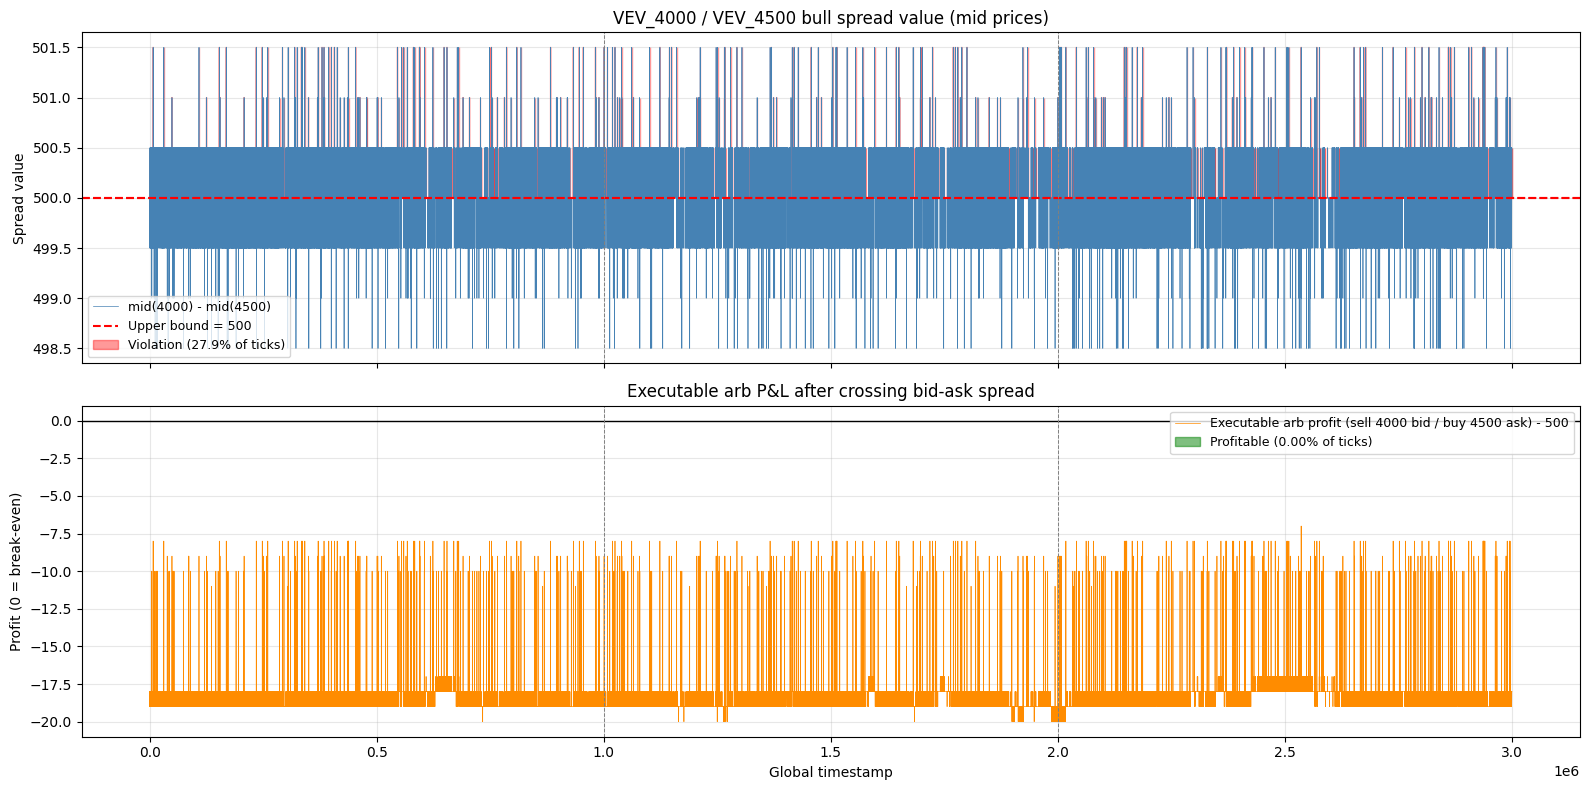

In [29]:
# ── Plot 2: VEV_4000/4500 spread time series vs 500 ceiling ──────────────────
# This is the most interesting near-arb: the spread at mid sometimes exceeds 500
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

spread_4k = mid_tbl['VEV_4000'] - mid_tbl['VEV_4500']
axes[0].plot(spread_4k.index, spread_4k, lw=0.5, color='steelblue', label='mid(4000) - mid(4500)')
axes[0].axhline(500, color='red', lw=1.5, ls='--', label='Upper bound = 500')
axes[0].axhline(500, color='red', lw=1.5, ls='--')
above_mask = spread_4k > 500
axes[0].fill_between(spread_4k.index, 500, spread_4k.where(above_mask),
                     color='red', alpha=0.4, label=f'Violation ({above_mask.mean()*100:.1f}% of ticks)')
axes[0].set_title('VEV_4000 / VEV_4500 bull spread value (mid prices)')
axes[0].set_ylabel('Spread value'); axes[0].legend(fontsize=9)

# Executable arb: sell 4000 at bid, buy 4500 at ask — profit vs ceiling 500
exec_credit = bid_tbl['VEV_4000'] - ask_tbl['VEV_4500']
exec_arb    = exec_credit - 500
axes[1].plot(exec_arb.index, exec_arb, lw=0.5, color='darkorange',
             label='Executable arb profit (sell 4000 bid / buy 4500 ask) - 500')
axes[1].axhline(0, color='black', lw=1)
arb_exec_mask = exec_arb > 0
axes[1].fill_between(exec_arb.index, 0, exec_arb.where(arb_exec_mask),
                     color='green', alpha=0.5, label=f'Profitable ({arb_exec_mask.mean()*100:.2f}% of ticks)')
axes[1].set_title('Executable arb P&L after crossing bid-ask spread')
axes[1].set_ylabel('Profit (0 = break-even)'); axes[1].legend(fontsize=9)
axes[1].set_xlabel('Global timestamp')

for d in DAYS[1:]:
    for ax in axes:
        ax.axvline((d-1)*TS_PER_DAY, color='grey', lw=0.7, ls='--')
plt.tight_layout(); plt.show()

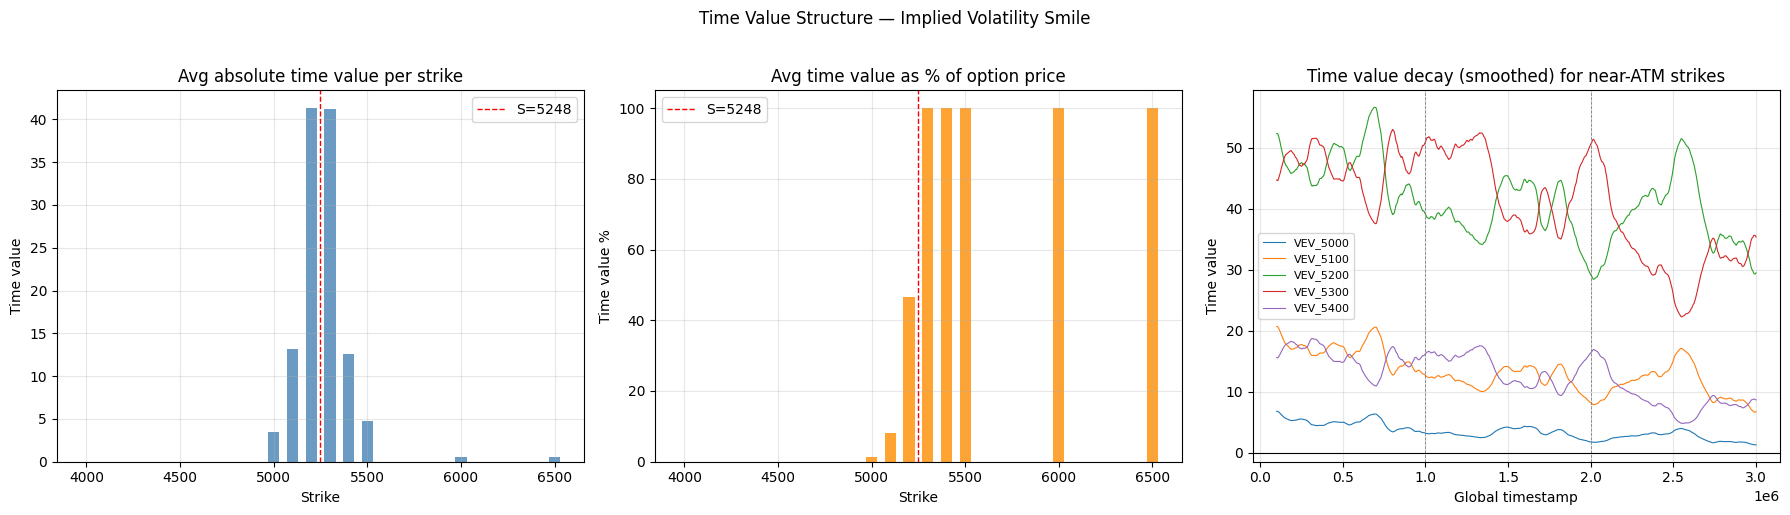

In [30]:
# ── Plot 3: Time value structure — the "implied vol smile" ───────────────────
# Time value as % of option price reveals how the market prices each strike's optionality
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tv_pct_mean = []
tv_abs_mean = []
for p in sorted_opts:
    K  = STRIKES[p]
    mp = mid_tbl[p].dropna()
    iv = (S_mid.reindex(mp.index) - K).clip(lower=0)
    tv = mp - iv
    tv_pct_mean.append(tv.mean() / mp.mean() * 100 if mp.mean() > 0 else 0)
    tv_abs_mean.append(tv.mean())

ks = [STRIKES[p] for p in sorted_opts]
axes[0].bar(ks, tv_abs_mean, width=60, color='steelblue', alpha=0.8)
axes[0].axvline(S_mid.mean(), color='red', ls='--', lw=1, label=f'S={S_mid.mean():.0f}')
axes[0].set_title('Avg absolute time value per strike')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Time value'); axes[0].legend()

axes[1].bar(ks, tv_pct_mean, width=60, color='darkorange', alpha=0.8)
axes[1].axvline(S_mid.mean(), color='red', ls='--', lw=1, label=f'S={S_mid.mean():.0f}')
axes[1].set_title('Avg time value as % of option price')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Time value %'); axes[1].legend()

# Time value over time for most interesting strikes
for i, p in enumerate(['VEV_5000','VEV_5100','VEV_5200','VEV_5300','VEV_5400']):
    if p not in mid_tbl.columns: continue
    K  = STRIKES[p]
    mp = mid_tbl[p]
    iv = (S_mid - K).clip(lower=0)
    tv = (mp - iv).rolling(1000).mean()
    axes[2].plot(tv.index, tv, lw=0.8, label=p)

for d in DAYS[1:]:
    axes[2].axvline((d-1)*TS_PER_DAY, color='grey', lw=0.6, ls='--')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Time value decay (smoothed) for near-ATM strikes')
axes[2].set_xlabel('Global timestamp'); axes[2].set_ylabel('Time value'); axes[2].legend(fontsize=8)

plt.suptitle('Time Value Structure — Implied Volatility Smile', y=1.02)
plt.tight_layout(); plt.show()

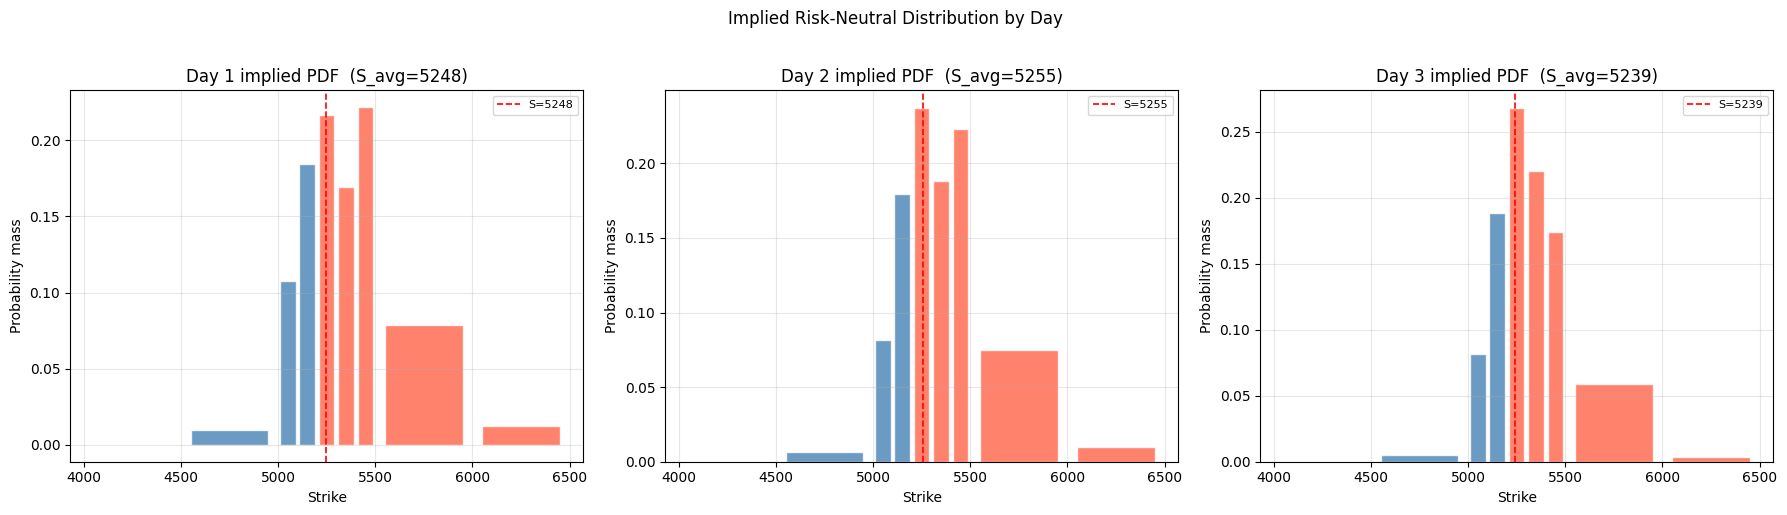

In [31]:
# ── Plot 4: How the implied distribution shifts through the 3 days ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for day_i, d in enumerate(DAYS):
    ax = axes[day_i]
    day_start = (d - 1) * TS_PER_DAY
    day_end   = d * TS_PER_DAY
    mask_day  = (mid_tbl.index >= day_start) & (mid_tbl.index < day_end)
    day_mids  = mid_tbl[mask_day]

    rn_day = []
    for i in range(len(sorted_opts) - 1):
        lo, hi = sorted_opts[i], sorted_opts[i+1]
        K_lo, K_hi = STRIKES[lo], STRIKES[hi]
        if lo not in day_mids.columns or hi not in day_mids.columns: continue
        spread = (day_mids[lo] - day_mids[hi]).mean()
        prob   = spread / (K_hi - K_lo)
        rn_day.append({'boundary': K_hi, 'prob': prob,
                       'K_diff': K_hi - K_lo, 'mass': None})

    # Compute mass
    all_probs  = [1.0] + [r['prob'] for r in rn_day]
    all_bounds = [STRIKES[sorted_opts[0]]] + [r['boundary'] for r in rn_day]
    masses     = [all_probs[i] - all_probs[i+1] for i in range(len(all_probs)-1)]
    mid_ks     = [(all_bounds[i]+all_bounds[i+1])/2 for i in range(len(all_bounds)-1)]
    w_arr      = [all_bounds[i+1]-all_bounds[i] for i in range(len(all_bounds)-1)]
    S_day      = day_mids[UNDERLYING].mean() if UNDERLYING in day_mids.columns else S_mid.mean()

    colors_d = ['steelblue' if all_bounds[i+1] <= S_day else 'tomato'
                for i in range(len(all_bounds)-1)]
    ax.bar(mid_ks, masses, width=[w*0.8 for w in w_arr],
           color=colors_d, alpha=0.8, edgecolor='white')
    ax.axvline(S_day, color='red', ls='--', lw=1.2, label=f'S={S_day:.0f}')
    ax.set_title(f'Day {d} implied PDF  (S_avg={S_day:.0f})')
    ax.set_xlabel('Strike'); ax.set_ylabel('Probability mass')
    ax.legend(fontsize=8)

plt.suptitle('Implied Risk-Neutral Distribution by Day', y=1.02)
plt.tight_layout(); plt.show()

In [32]:
# ── Final arbitrage summary ───────────────────────────────────────────────────
print('=' * 65)
print('ARBITRAGE SUMMARY')
print('=' * 65)
print()
print('RISK-FREE (model-free) ARBITRAGE:')
print('  Check 1 Negative time value : None at executable prices')
print('  Check 2 Monotonicity        : None at executable prices')
print('  Check 3 Bull spread upper   : None at executable prices')
print('  Check 4 Butterfly convexity : None at executable prices')
print()
print('NEAR-ARB / STRUCTURAL OBSERVATIONS:')
print()
print(f'  [A] VEV_4000/VEV_4500 SPREAD DISLOCATION')
print(f'      Mid-price spread exceeds 500 (the strike diff) on {above_mask.mean()*100:.1f}% of ticks.')
print(f'      Avg excess at mid = {(spread_4k - 500).clip(lower=0).mean():.2f}.')
print(f'      These options have ~0 time value, so both track intrinsic exactly.')
print(f'      When VEV_4000 bid > VEV_4500 ask + 500 (rare), a true arb opens.')
print()

print(f'  [B] DEEP-ITM OPTIONS PRICE AT INTRINSIC (zero time premium)')
print(f'      VEV_4000 time value: {tv_abs_mean[0]:.2f}  ({tv_pct_mean[0]:.1f}% of price)')
print(f'      VEV_4500 time value: {tv_abs_mean[1]:.2f}  ({tv_pct_mean[1]:.1f}% of price)')
print(f'      Market implies zero probability of S_T < 4500.')
print(f'      Implication: these options trade like forwards, not options.')
print()

print(f'  [C] IMPLIED DISTRIBUTION IS TIGHTLY CENTRED')
prob_above_5500 = (mid_tbl['VEV_5000'] - mid_tbl['VEV_5500']).mean() / 500
prob_above_5300 = (mid_tbl['VEV_5000'] - mid_tbl['VEV_5300']).mean() / 300
print(f'      P(S_T > 5300) implied by options ~ {prob_above_5300:.2f}')
print(f'      P(S_T > 5500) implied by options ~ {prob_above_5500:.3f}')
print(f'      Current S ~ {S_mid.mean():.0f}; market implies S almost never exceeds 5500.')
print(f'      If you believe S can drift to 5500+, VEV_5400/5500 look underpriced.')
print()

print(f'  [D] FLOOR PRICING FOR DEEP-OTM (6000, 6500)')
p6k  = mid_tbl['VEV_6000'].mean()
p65k = mid_tbl['VEV_6500'].mean()
print(f'      VEV_6000 avg price = {p6k:.2f}  (floored at 0.5)')
print(f'      VEV_6500 avg price = {p65k:.2f}  (floored at 0.5)')
print(f'      Their spread = {p6k - p65k:.2f} (should be >=0, but ~ 0 means market')
print(f'      treats both as equally worthless lottery tickets.')
print()

print('TRADING IMPLICATIONS:')
print('  - No free lunch exists; options are correctly convex and monotone')
print('  - Best relative value: sell VEV_5200/5300 (richest time-value premium)')
print('    and buy VEV_5400/5500 (cheap time value, OTM lottery)') 
print('  - Watch VEV_4000/4500 spread for moments when it spikes above 500 at mid;')
print('    a limit order to sell 4000 / buy 4500 with net > 500 locks in risk-free profit')
print('  - If underlying drifts UP in day 3, OTM calls 5400+ have convex payoff')

ARBITRAGE SUMMARY

RISK-FREE (model-free) ARBITRAGE:
  Check 1 Negative time value : None at executable prices
  Check 2 Monotonicity        : None at executable prices
  Check 3 Bull spread upper   : None at executable prices
  Check 4 Butterfly convexity : None at executable prices

NEAR-ARB / STRUCTURAL OBSERVATIONS:

  [A] VEV_4000/VEV_4500 SPREAD DISLOCATION
      Mid-price spread exceeds 500 (the strike diff) on 27.9% of ticks.
      Avg excess at mid = 0.15.
      These options have ~0 time value, so both track intrinsic exactly.
      When VEV_4000 bid > VEV_4500 ask + 500 (rare), a true arb opens.

  [B] DEEP-ITM OPTIONS PRICE AT INTRINSIC (zero time premium)
      VEV_4000 time value: 0.01  (0.0% of price)
      VEV_4500 time value: 0.01  (0.0% of price)
      Market implies zero probability of S_T < 4500.
      Implication: these options trade like forwards, not options.

  [C] IMPLIED DISTRIBUTION IS TIGHTLY CENTRED
      P(S_T > 5300) implied by options ~ 0.70
      P(S_T 